PCA Reduced Features (first 5 samples):
[[-0.19555069 -1.46569954]
 [ 0.99909775 -0.28157533]
 [ 1.29038684  0.41360693]
 [ 0.8040593   0.27890553]
 [ 2.32432379  1.83158841]]

LDA Reduced Features (first 5 samples):
[[-0.5146117   1.8827288 ]
 [-3.54963835  0.71534143]
 [-4.52775094 -0.40017466]
 [-1.03648014 -0.0111809 ]
 [-5.97596835 -2.75981048]]

Classification Accuracy:
PCA Accuracy: 0.9111111111111111
LDA Accuracy: 1.0


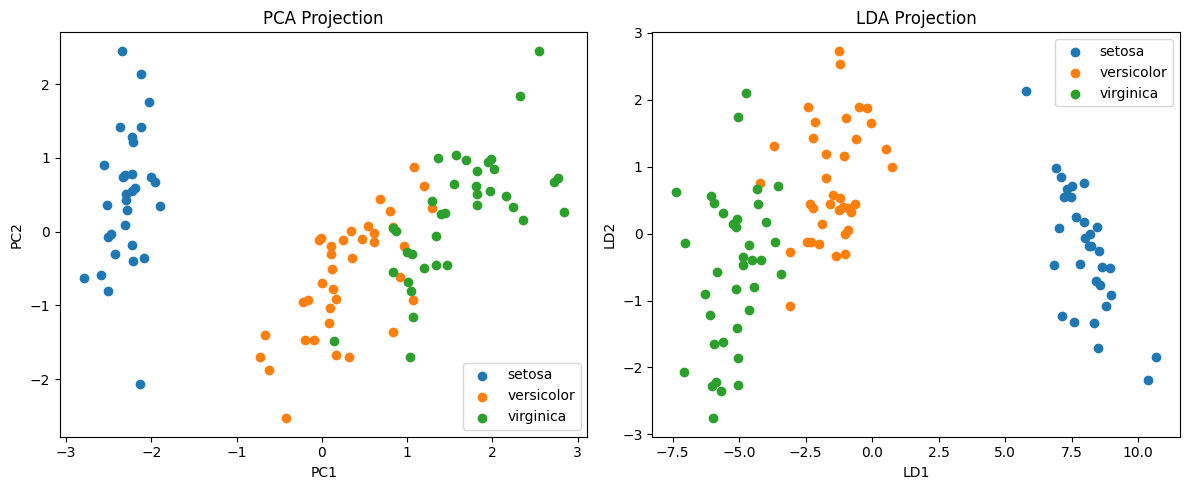

In [ ]:
#Exp 4
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# -------------------------
# Apply PCA
# -------------------------
pca = PCA(n_components=2)
X_pca_train = pca.fit_transform(X_train)
X_pca_test = pca.transform(X_test)

# -------------------------
# Apply LDA
# -------------------------
lda = LDA(n_components=2)
X_lda_train = lda.fit_transform(X_train, y_train)
X_lda_test = lda.transform(X_test)

# Display reduced features (first 5 rows)
print("PCA Reduced Features (first 5 samples):")
print(X_pca_train[:5])

print("\nLDA Reduced Features (first 5 samples):")
print(X_lda_train[:5])

# -------------------------
# Classification comparison
# -------------------------
model = LogisticRegression()

# Using PCA features
model.fit(X_pca_train, y_train)
y_pred_pca = model.predict(X_pca_test)
acc_pca = accuracy_score(y_test, y_pred_pca)

# Using LDA features
model.fit(X_lda_train, y_train)
y_pred_lda = model.predict(X_lda_test)
acc_lda = accuracy_score(y_test, y_pred_lda)

print("\nClassification Accuracy:")
print("PCA Accuracy:", acc_pca)
print("LDA Accuracy:", acc_lda)

# -------------------------
# Plot 2D projections
# -------------------------
plt.figure(figsize=(12, 5))

# PCA Plot
plt.subplot(1, 2, 1)
for i, label in enumerate(np.unique(y)):
    plt.scatter(
        X_pca_train[y_train == label, 0],
        X_pca_train[y_train == label, 1],
        label=iris.target_names[label]
    )
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

# LDA Plot
plt.subplot(1, 2, 2)
for i, label in enumerate(np.unique(y)):
    plt.scatter(
        X_lda_train[y_train == label, 0],
        X_lda_train[y_train == label, 1],
        label=iris.target_names[label]
    )
plt.title("LDA Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()

plt.tight_layout()
plt.show()